In [1]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from math import log, sqrt
from statistics import NormalDist

In [2]:
class BlackScholes:
    def __init__(self, spot, strike, time_to_expiry):
        self.spot = spot
        self.strike = strike
        self.time_to_expiry = time_to_expiry

    def call_price(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        d2 = d1 - volatility * sqrt(self.time_to_expiry)
        call_price = self.spot * NormalDist().cdf(d1) - self.strike * NormalDist().cdf(d2)
        return call_price

    def delta(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().cdf(d1)

    def gamma(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().pdf(d1) / (self.spot * volatility * sqrt(self.time_to_expiry))

    def vega(self, volatility):
        d1 = (
            log(self.spot) - log(self.strike) + (0.5 * volatility * volatility) * self.time_to_expiry
        ) / (volatility * sqrt(self.time_to_expiry))
        return NormalDist().pdf(d1) * (self.spot * sqrt(self.time_to_expiry)) / 100

    def implied_volatility(self, market_call_price, max_iterations=200, tolerance=1e-10):
        low_vol = 0.01
        high_vol = 5.0
        volatility = (low_vol + high_vol) / 2.0  # Initial guess as the midpoint
        for _ in range(max_iterations):
            estimated_price = self.call_price(volatility)
            diff = estimated_price - market_call_price
            if abs(diff) < tolerance:
                break
            elif diff > 0:
                high_vol = volatility
            else:
                low_vol = volatility
            volatility = (low_vol + high_vol) / 2.0
        return volatility

In [3]:
def calc_time_to_expiry(day, ts):
    return (8 - day) / 250 - ts / 1_000_000 / 250

In [4]:
def calc_implied_vol(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.implied_volatility(x['filtered_mid'])

In [5]:
def calc_delta(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.delta(x['implied_vol'])

In [6]:
def calc_gamma(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.gamma(x['implied_vol'])

In [7]:
def calc_vega(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    bs = BlackScholes(spot=x['spot'], strike=x['strike'], time_to_expiry=tte)
    return bs.vega(x['implied_vol'])

In [8]:
def calc_moneyness(x):
    tte = calc_time_to_expiry(x['day'], x['timestamp'])
    return np.log(x['strike'] / x['spot']) / np.sqrt(tte)

In [9]:
def calc_filtered_mid(df, threshold=15):
    """
    Calculates a filtered mid-price, safely ignoring NaN values 
    in the order book data.
    """
    # 1. Extract Arrays
    b_px = df[['bid_price_1', 'bid_price_2', 'bid_price_3']].values
    b_vol = df[['bid_volume_1', 'bid_volume_2', 'bid_volume_3']].values
    a_px = df[['ask_price_1', 'ask_price_2', 'ask_price_3']].values
    a_vol = df[['ask_volume_1', 'ask_volume_2', 'ask_volume_3']].values

    # 2. Safely handle volume NaNs (treat missing volume as 0)
    b_vol_safe = np.nan_to_num(b_vol, nan=0.0)
    a_vol_safe = np.nan_to_num(a_vol, nan=0.0)

    b_mask = b_vol_safe >= threshold
    a_mask = a_vol_safe >= threshold

    # 3. Process Bids
    valid_b_px = np.where(b_mask, b_px, -np.inf)
    # Use nanmax to ignore NaNs in the price columns
    best_b_px_filtered = np.nanmax(valid_b_px, axis=1)
    
    fallback_b_idx = np.argmax(b_vol_safe, axis=1)
    fallback_b_px = b_px[np.arange(len(b_px)), fallback_b_idx]
    
    final_bid = np.where(np.any(b_mask, axis=1), best_b_px_filtered, fallback_b_px)

    # 4. Process Asks
    valid_a_px = np.where(a_mask, a_px, np.inf)
    # Use nanmin to ignore NaNs in the price columns
    best_a_px_filtered = np.nanmin(valid_a_px, axis=1)
    
    fallback_a_idx = np.argmax(a_vol_safe, axis=1)
    fallback_a_px = a_px[np.arange(len(a_px)), fallback_a_idx]
    
    final_ask = np.where(np.any(a_mask, axis=1), best_a_px_filtered, fallback_a_px)

    # 5. Calculate the filtered mid price
    filtered_mid = (final_bid + final_ask) / 2
    filtered_mid = pd.Series(filtered_mid).ffill()

    return filtered_mid

# Price

In [426]:
price = pd.read_csv('../data/raw/round_4/prices_round_4_day_1.csv', delimiter=';').drop(columns=['profit_and_loss'])
products = sorted(list(price['product'].unique()))
strikes = [int(x[4:]) for x in products if x[:3] == 'VEV']
atm_strikes = [5000, 5100, 5200, 5300, 5400, 5500]

price_velvet = price[price['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev = {}
for s in strikes:
    price_vev[s] = price[price['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev[s] = price_vev[s].assign(strike=s)

price_1 = pd.read_csv('../data/raw/round_4/prices_round_4_day_2.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_velvet_1 = price_1[price_1['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev_1 = {}
for s in strikes:
    price_vev_1[s] = price_1[price_1['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev_1[s] = price_vev_1[s].assign(strike=s)

price_2 = pd.read_csv('../data/raw/round_4/prices_round_4_day_3.csv', delimiter=';').drop(columns=['profit_and_loss'])
price_velvet_2 = price_2[price_2['product'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
price_vev_2 = {}
for s in strikes:
    price_vev_2[s] = price_2[price_2['product'] == f'VEV_{s}'].reset_index(drop=True)
    price_vev_2[s] = price_vev_2[s].assign(strike=s)

## VELVETFRUIT_EXTRACT

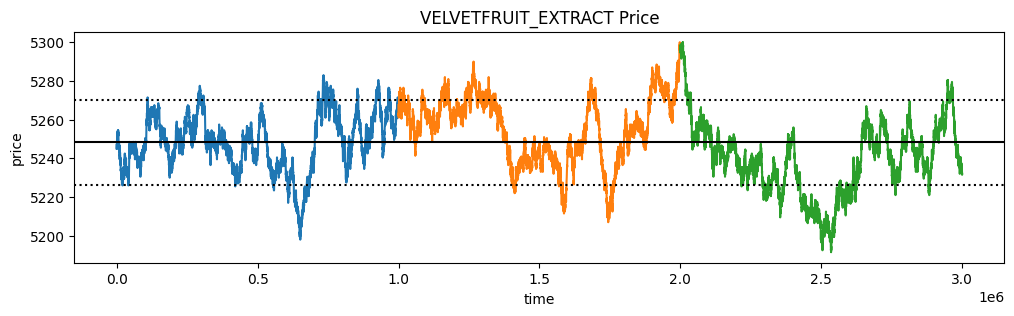

In [427]:
plt.figure(figsize=(12, 3))
plt.plot(price_velvet['timestamp'], price_velvet['mid_price'])
plt.plot(price_velvet_1['timestamp'] + 1000000, price_velvet_1['mid_price'])
plt.plot(price_velvet_2['timestamp'] + 2000000, price_velvet_2['mid_price'])
plt.axhline(price_velvet['mid_price'].mean(), c='k')
plt.axhline(price_velvet['mid_price'].mean() + 1.5 * price_velvet['mid_price'].std(), c='k', linestyle='dotted')
plt.axhline(price_velvet['mid_price'].mean() - 1.5 * price_velvet['mid_price'].std(), c='k', linestyle='dotted')
plt.title('VELVETFRUIT_EXTRACT Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

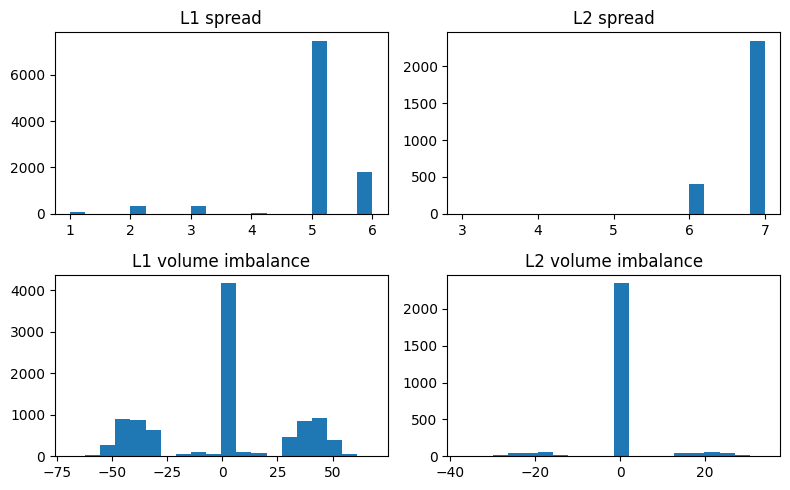

In [428]:
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
ax[0, 0].hist(price_velvet['ask_price_1'] - price_velvet['bid_price_1'], bins=20)
ax[0, 1].hist(price_velvet['ask_price_2'] - price_velvet['bid_price_2'], bins=20)
ax[1, 0].hist(price_velvet['ask_volume_1'] - price_velvet['bid_volume_1'], bins=20)
ax[1, 1].hist(price_velvet['ask_volume_2'] - price_velvet['bid_volume_2'], bins=20)
ax[0, 0].set_title('L1 spread')
ax[0, 1].set_title('L2 spread')
ax[1, 0].set_title('L1 volume imbalance')
ax[1, 1].set_title('L2 volume imbalance')
plt.tight_layout()
plt.show()

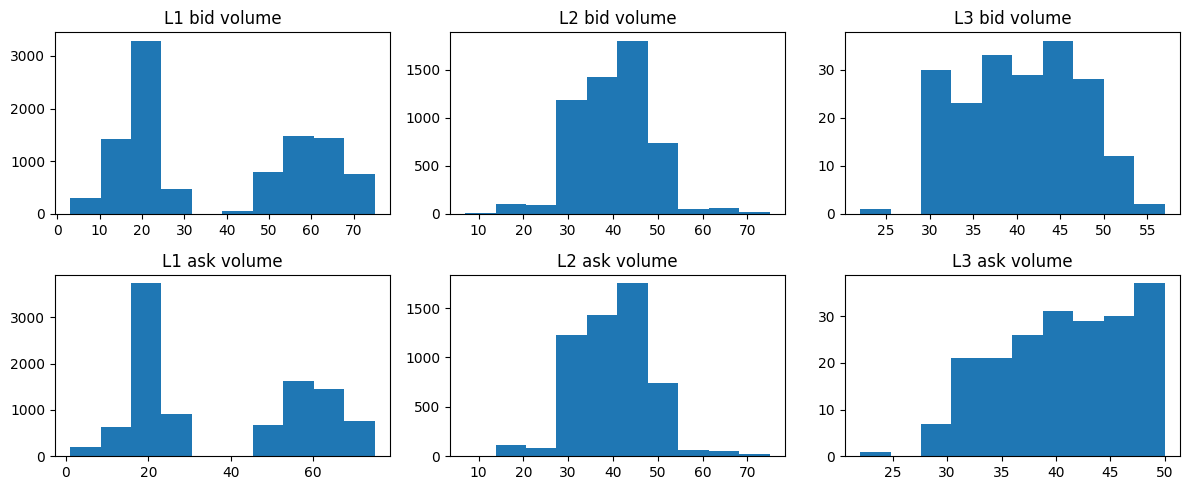

In [429]:
fig, ax = plt.subplots(2, 3, figsize=(12, 5))
ax[0, 0].hist(price_velvet['bid_volume_1'])
ax[0, 1].hist(price_velvet['bid_volume_2'])
ax[0, 2].hist(price_velvet['bid_volume_3'])
ax[1, 0].hist(price_velvet['ask_volume_1'])
ax[1, 1].hist(price_velvet['ask_volume_2'])
ax[1, 2].hist(price_velvet['ask_volume_3'])
ax[0, 0].set_title('L1 bid volume')
ax[0, 1].set_title('L2 bid volume')
ax[0, 2].set_title('L3 bid volume')
ax[1, 0].set_title('L1 ask volume')
ax[1, 1].set_title('L2 ask volume')
ax[1, 2].set_title('L3 ask volume')
plt.tight_layout()
plt.show()

In [430]:
price_velvet = price_velvet.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))
price_velvet_1 = price_velvet_1.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))
price_velvet_2 = price_velvet_2.assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=15))

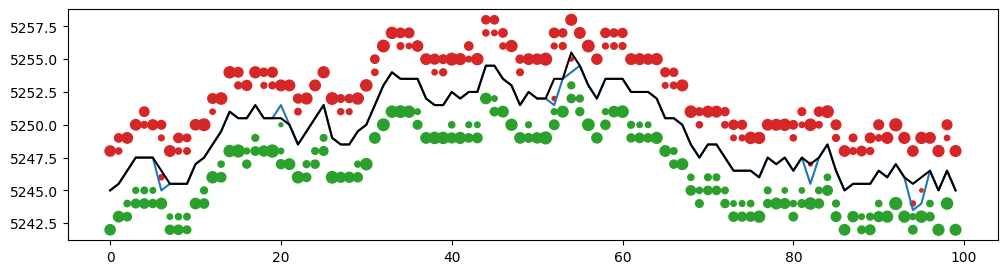

In [431]:
l = 100
plt.figure(figsize=(12, 3))
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_1'], s=price_velvet.iloc[:l]['bid_volume_1'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_2'], s=price_velvet.iloc[:l]['bid_volume_2'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['bid_price_3'], s=price_velvet.iloc[:l]['bid_volume_3'], c='tab:green')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_1'], s=price_velvet.iloc[:l]['ask_volume_1'], c='tab:red')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_2'], s=price_velvet.iloc[:l]['ask_volume_2'], c='tab:red')
plt.scatter(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['ask_price_3'], s=price_velvet.iloc[:l]['ask_volume_3'], c='tab:red')
plt.plot(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['mid_price'])
plt.plot(price_velvet.iloc[:l]['timestamp']//100, price_velvet.iloc[:l]['filtered_mid'], c='k')
plt.show()

In [432]:
print(price_velvet['filtered_mid'].mean(), price_velvet_1['filtered_mid'].mean(), price_velvet_2['filtered_mid'].mean())
print(pd.concat([price_velvet['filtered_mid'], price_velvet_1['filtered_mid'], price_velvet_2['filtered_mid']]).reset_index(drop=True).mean())
print(price_velvet['filtered_mid'].std(), price_velvet_1['filtered_mid'].std(), price_velvet_2['filtered_mid'].std())
print(pd.concat([price_velvet['filtered_mid'], price_velvet_1['filtered_mid'], price_velvet_2['filtered_mid']]).reset_index(drop=True).std())

5248.4127 5255.4079 5239.179
5247.666533333333
14.611243189843748 16.98363659471075 18.59345935196211
18.07503545996849


In [433]:
velvet_mean = 5248
velvet_std = 18

In [434]:
price_velvet = price_velvet.set_index('timestamp', drop=True)
price_velvet_1 = price_velvet_1.set_index('timestamp', drop=True)
price_velvet_2 = price_velvet_2.set_index('timestamp', drop=True)

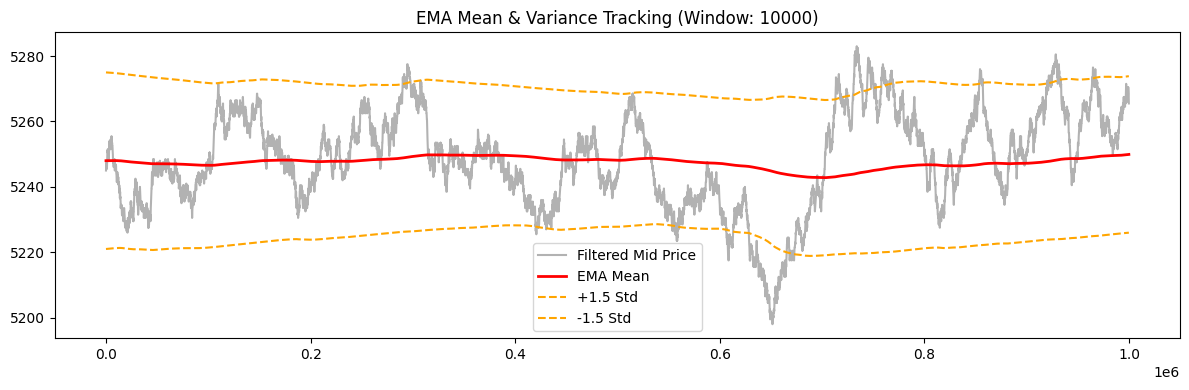

In [435]:
# 1. Initial States (Historical Hardcoded Values)
ema_mean = velvet_mean
ema_var = velvet_std ** 2

# 2. The Tuning Parameter (Equivalent to Q in the Kalman Filter)
# A smaller window adapts faster to regime shifts but is noisier.
# A larger window is more stubborn but slower to catch up to big moves.
window_size = 10000
alpha = 2 / (window_size + 1)

estimated_means = []
estimated_stds = []

# 3. EMA Updating Loop
for price in price_velvet['filtered_mid']:
    # Calculate difference from the *old* mean
    diff = price - ema_mean
    
    # Update Variance FIRST (Mathematically requires the difference from the old mean)
    ema_var = (1 - alpha) * ema_var + alpha * (diff ** 2)
    
    # Update Mean SECOND
    ema_mean = ema_mean + (alpha * diff)
    
    # Calculate instantaneous dynamic standard deviation
    current_std = math.sqrt(ema_var)
    
    estimated_means.append(ema_mean)
    estimated_stds.append(current_std)

# 4. Save to DataFrame
price_velvet['estimated_mean'] = estimated_means
price_velvet['estimated_std'] = estimated_stds

# 5. Plotting (With your exact 1.5 Std Dev bands)
plt.figure(figsize=(12, 4))
plt.plot(price_velvet['filtered_mid'], label='Filtered Mid Price', color='gray', alpha=0.6)
plt.plot(price_velvet['estimated_mean'], label='EMA Mean', color='red', linewidth=2)
plt.plot(price_velvet['estimated_mean'] + 1.5 * price_velvet['estimated_std'], color='orange', linestyle='--', label='+1.5 Std')
plt.plot(price_velvet['estimated_mean'] - 1.5 * price_velvet['estimated_std'], color='orange', linestyle='--', label='-1.5 Std')

plt.title(f'EMA Mean & Variance Tracking (Window: {window_size})')
plt.legend()
plt.tight_layout()
plt.show()

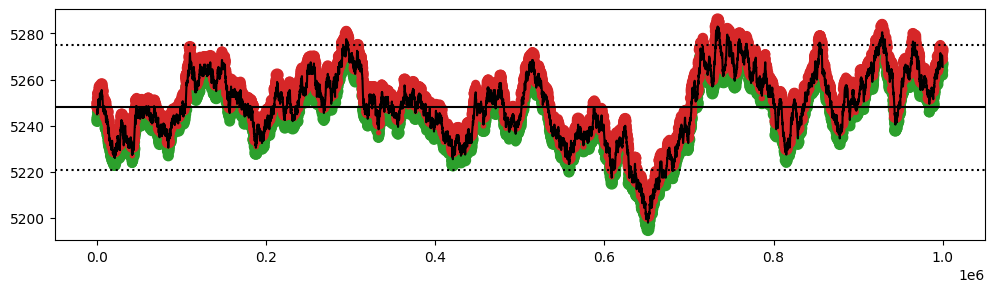

In [436]:
plt.figure(figsize=(12, 3))
plt.scatter(price_velvet.index, price_velvet['bid_price_1'], s=price_velvet['bid_volume_1'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['bid_price_2'], s=price_velvet['bid_volume_2'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['bid_price_3'], s=price_velvet['bid_volume_3'], c='tab:green')
plt.scatter(price_velvet.index, price_velvet['ask_price_1'], s=price_velvet['ask_volume_1'], c='tab:red')
plt.scatter(price_velvet.index, price_velvet['ask_price_2'], s=price_velvet['ask_volume_2'], c='tab:red')
plt.scatter(price_velvet.index, price_velvet['ask_price_3'], s=price_velvet['ask_volume_3'], c='tab:red')
plt.plot(price_velvet['filtered_mid'], c='k')
plt.axhline(velvet_mean, c='k')
plt.axhline(velvet_mean + 1.5 * velvet_std, c='k', linestyle='dotted')
plt.axhline(velvet_mean - 1.5 * velvet_std, c='k', linestyle='dotted')
plt.show()

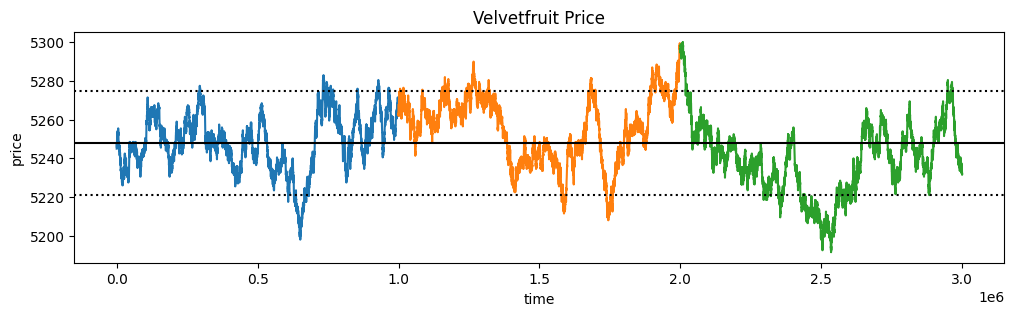

In [437]:
plt.figure(figsize=(12, 3))
plt.plot(price_velvet.index, price_velvet['filtered_mid'])
plt.plot(price_velvet_1.index + 1000000, price_velvet_1['filtered_mid'])
plt.plot(price_velvet_2.index + 2000000, price_velvet_2['filtered_mid'])
plt.axhline(velvet_mean, c='k')
plt.axhline(velvet_mean + 1.5 * velvet_std, c='k', linestyle='dotted')
plt.axhline(velvet_mean - 1.5 * velvet_std, c='k', linestyle='dotted')
plt.title('Velvetfruit Price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [438]:
train_logr = np.log(price_velvet['filtered_mid']).diff().dropna()
test_logr = np.log(price_velvet_1['filtered_mid']).diff().dropna()

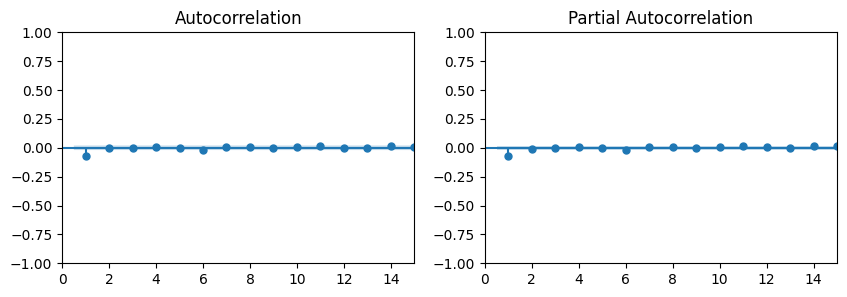

In [439]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
plot_acf(train_logr, ax=ax[0], zero=False)
plot_pacf(train_logr, ax=ax[1], zero=False)
ax[0].set_xlim([0, 15])
ax[1].set_xlim([0, 15])
plt.show()

In [440]:
# Perform Ljung-Box test for lags up to 10
result = acorr_ljungbox(train_logr, lags=[10], return_df=True)
print(result)

# Interpretation
if result['lb_pvalue'].values[0] > 0.05:
    print("Fail to reject null hypothesis: data may be white noise.")
else:
    print("Reject null hypothesis: data is not white noise.")

      lb_stat     lb_pvalue
10  52.702729  8.454681e-08
Reject null hypothesis: data is not white noise.


In [441]:
true = test_logr[1:].to_numpy()

In [442]:
# Naive
pred = test_logr[:-1].to_numpy()
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'Naive RMSE: {rmse}')

Naive RMSE: 0.0002783974061974017


In [443]:
# AR(1)
coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
a, b = coeffs
print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')

pred = test_logr[:-1].to_numpy() * a
err = true - pred
rmse = np.mean(err ** 2) ** 0.5
print(f'AR(1) RMSE: {rmse}')

Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.00019080192978617136


In [444]:
spread = (price_velvet['ask_price_1'] - price_velvet['bid_price_1']).median()
vol = price_velvet['mid_price'].std()
print("Velvet spread and daily std:")
print(f"{spread}, {vol}")

Velvet spread and daily std:
5.0, 14.61436185220671


## VEV

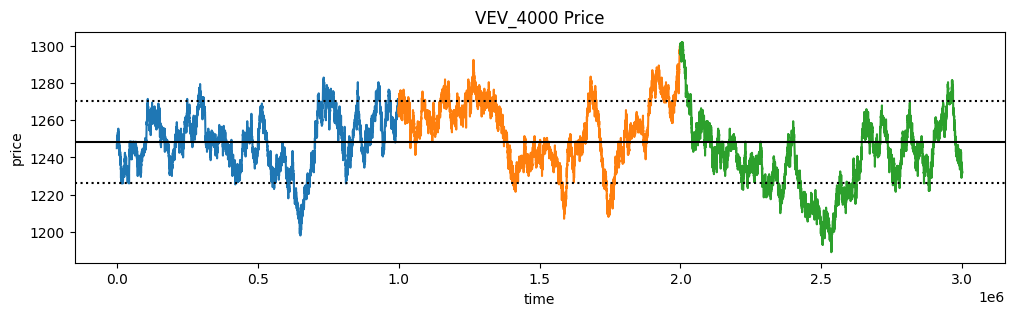

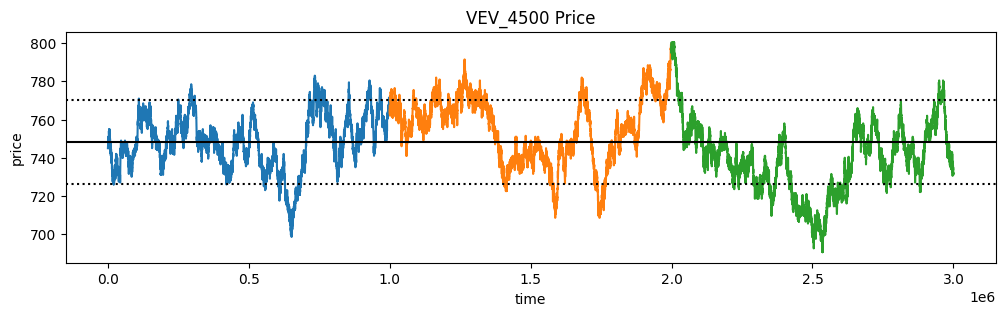

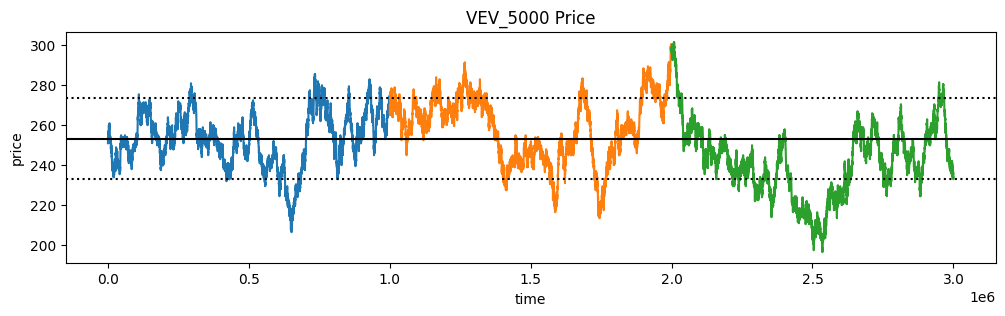

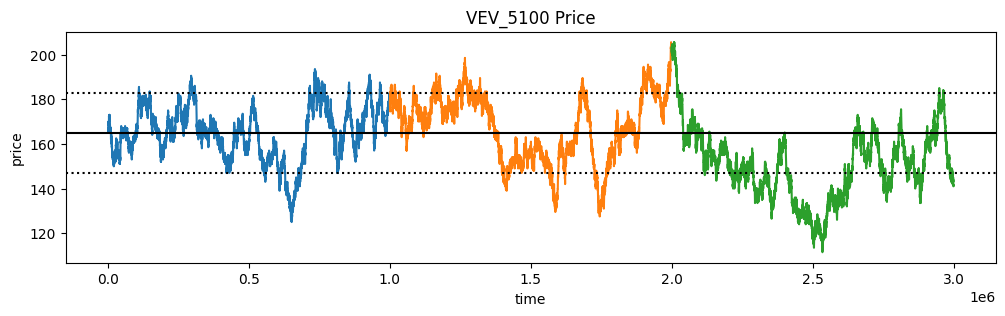

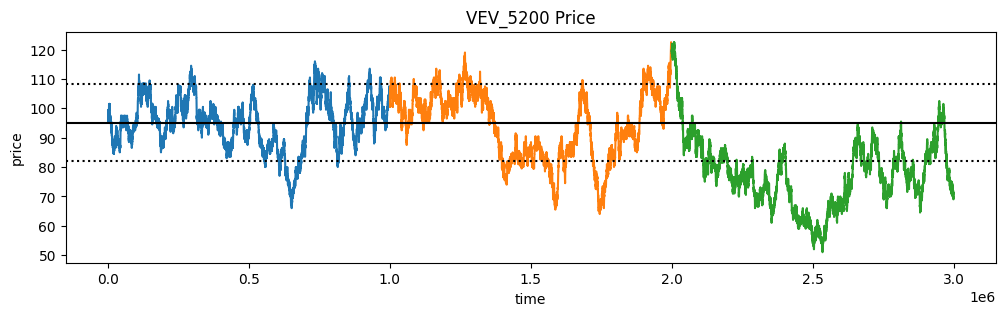

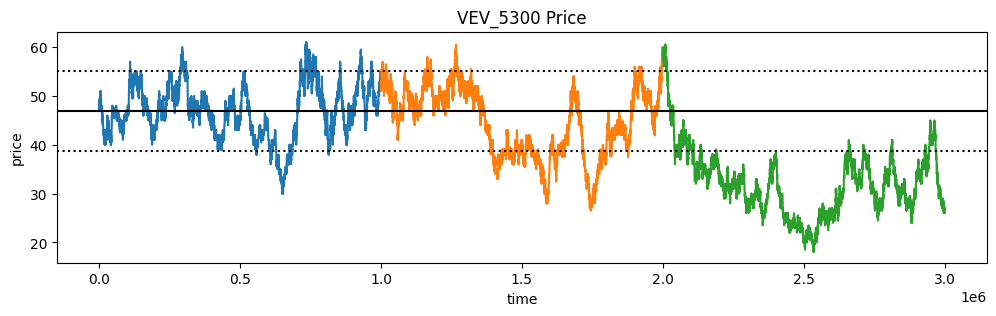

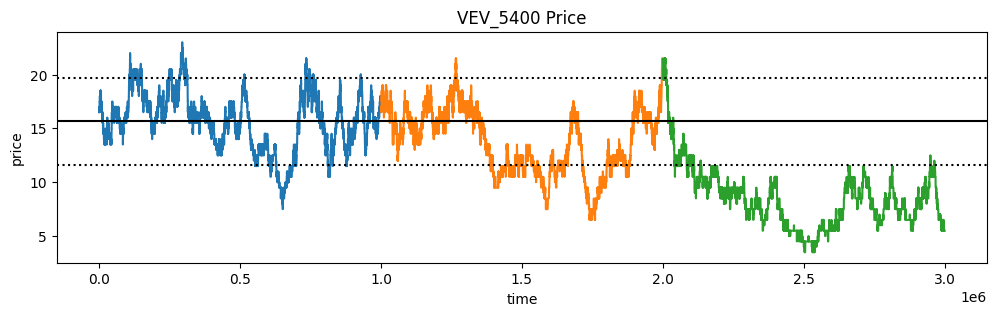

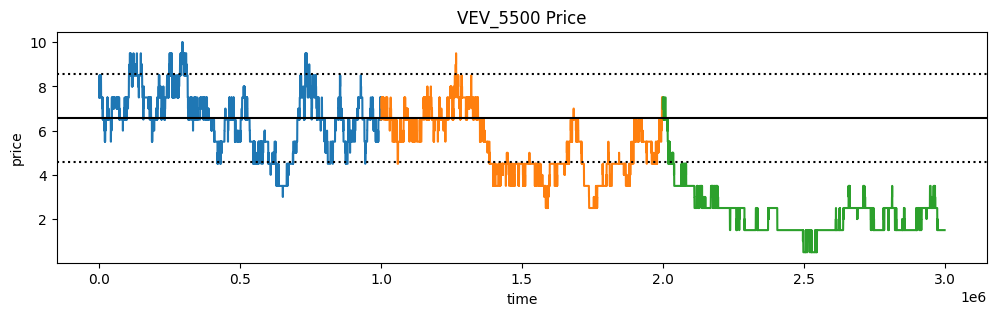

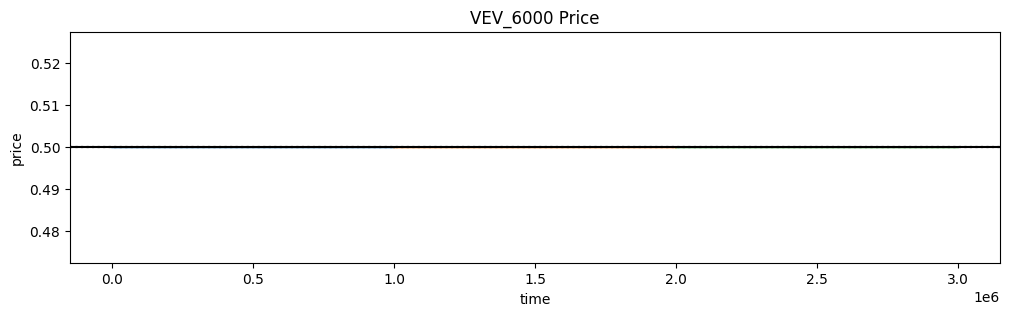

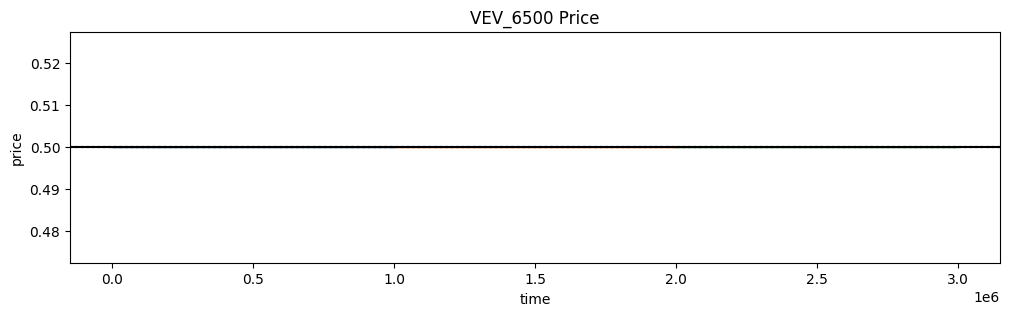

In [445]:
for strike in strikes:
    plt.figure(figsize=(12, 3))
    plt.plot(price_vev[strike]['timestamp'], price_vev[strike]['mid_price'])
    plt.plot(price_vev_1[strike]['timestamp'] + 1000000, price_vev_1[strike]['mid_price'])
    plt.plot(price_vev_2[strike]['timestamp'] + 2000000, price_vev_2[strike]['mid_price'])
    plt.axhline(price_vev[strike]['mid_price'].mean(), c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean() + 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.axhline(price_vev[strike]['mid_price'].mean() - 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.title(f'VEV_{strike} Price')
    plt.xlabel('time')
    plt.ylabel('price')
    plt.show()

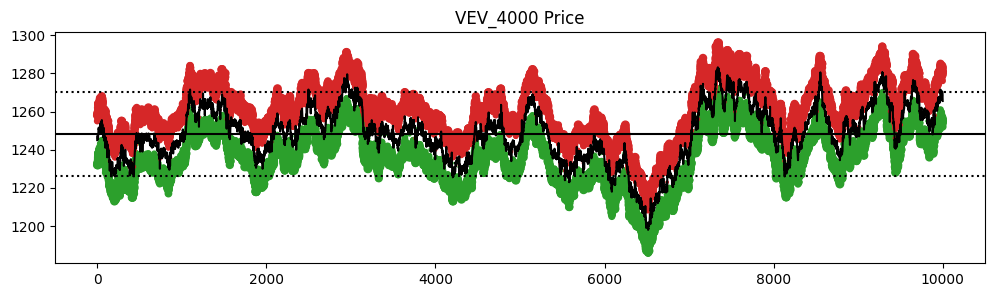

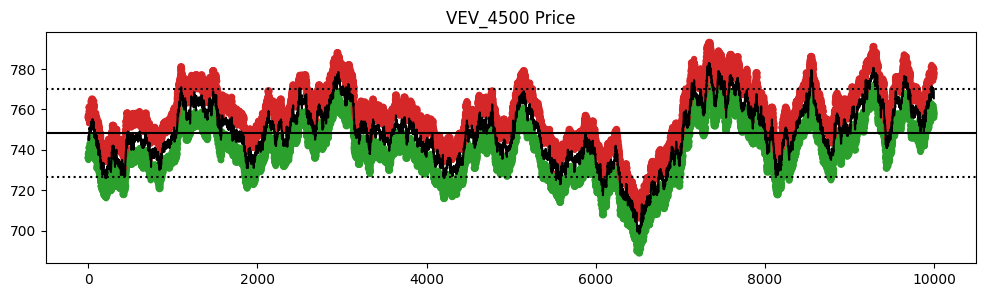

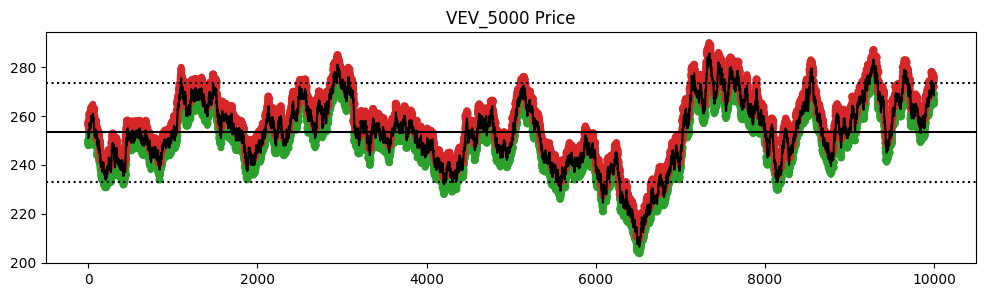

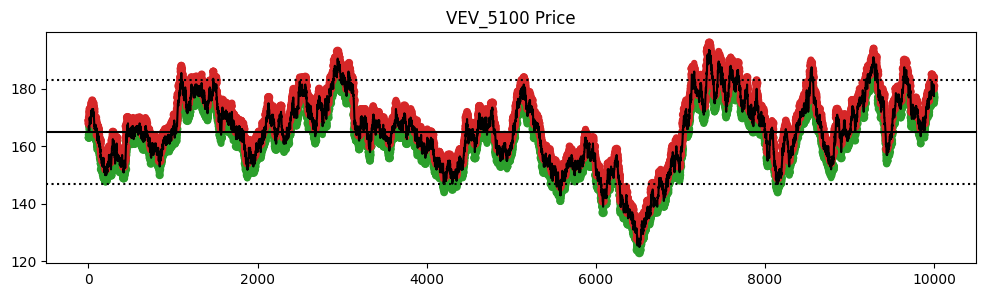

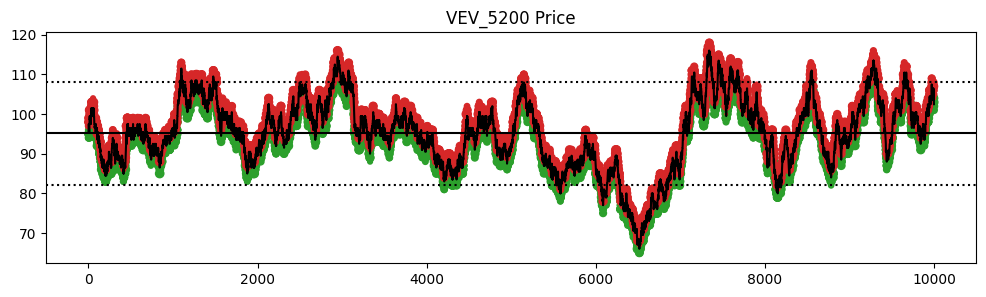

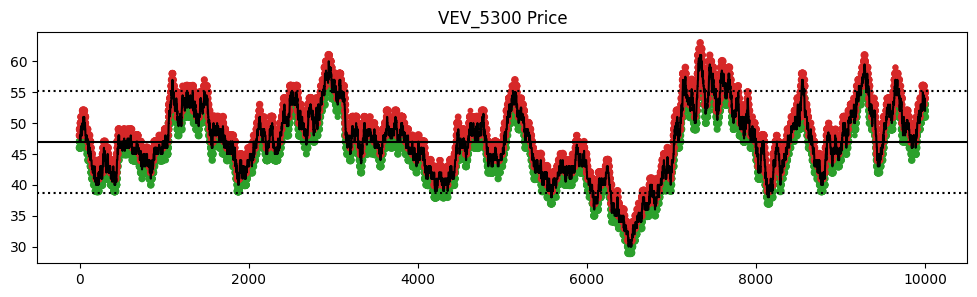

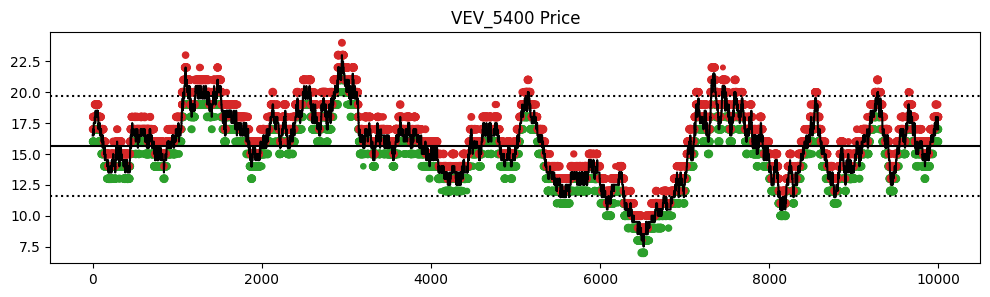

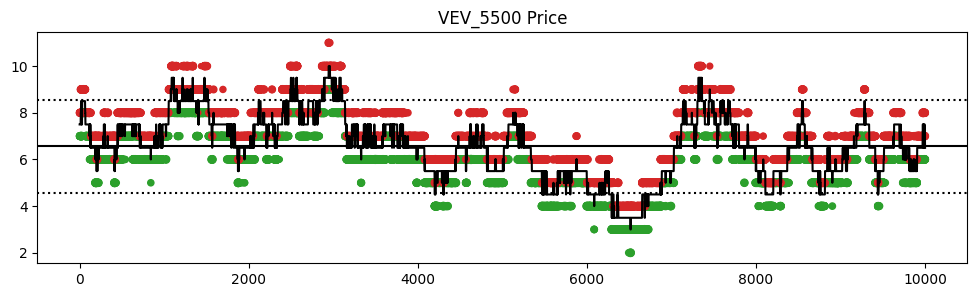

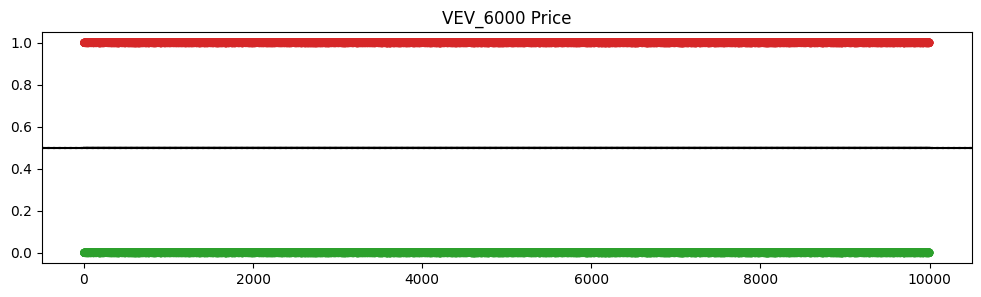

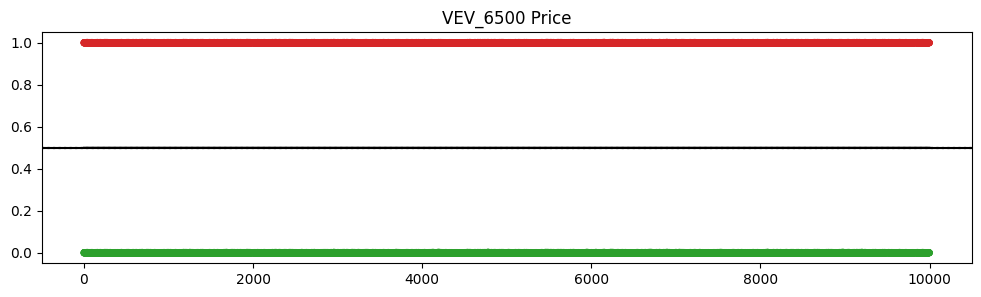

In [446]:
for strike in strikes:
    plt.figure(figsize=(12, 3))
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_1'], s=price_vev[strike]['bid_volume_1'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_2'], s=price_vev[strike]['bid_volume_2'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['bid_price_3'], s=price_vev[strike]['bid_volume_3'], c='tab:green')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_1'], s=price_vev[strike]['ask_volume_1'], c='tab:red')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_2'], s=price_vev[strike]['ask_volume_2'], c='tab:red')
    plt.scatter(price_vev[strike]['timestamp']//100, price_vev[strike]['ask_price_3'], s=price_vev[strike]['ask_volume_3'], c='tab:red')
    plt.plot(price_vev[strike]['timestamp']//100, price_vev[strike]['mid_price'], c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean(), c='k')
    plt.axhline(price_vev[strike]['mid_price'].mean() + 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.axhline(price_vev[strike]['mid_price'].mean() - 1.5 * price_vev[strike]['mid_price'].std(), c='k', linestyle='dotted')
    plt.title(f'VEV_{strike} Price')
    plt.show()

In [447]:
selected_strikes = strikes[:8]

In [448]:
selected_strikes

[4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500]

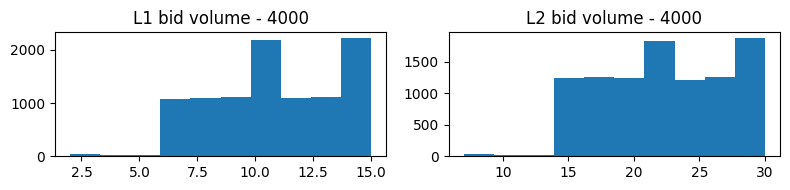

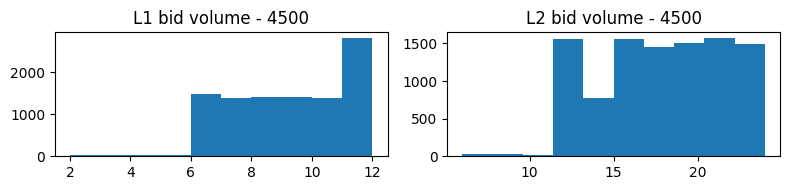

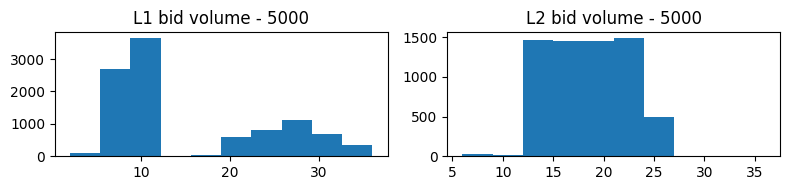

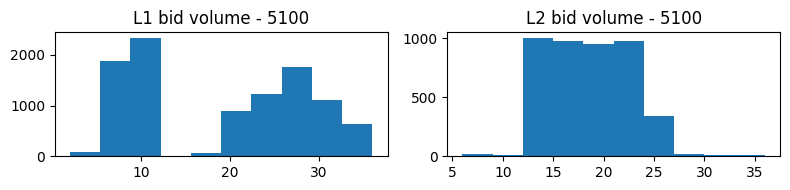

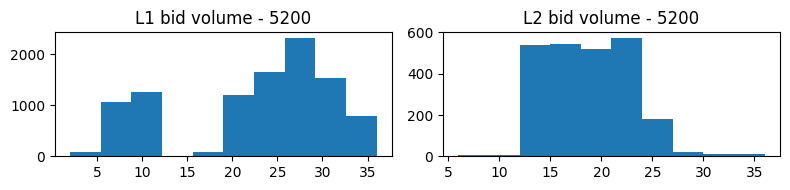

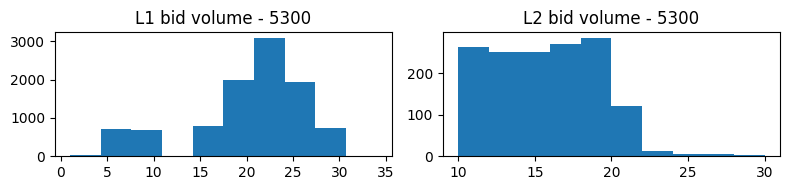

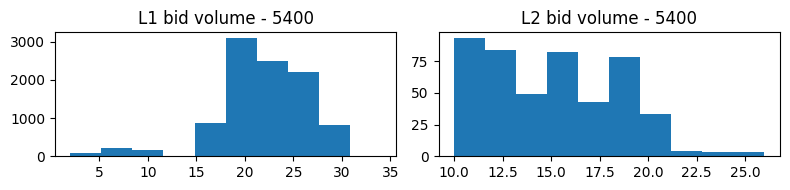

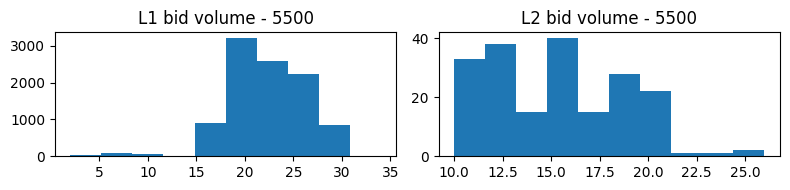

In [449]:
for strike in selected_strikes:
    fig, ax = plt.subplots(1, 2, figsize=(8, 2))
    ax[0].hist(price_vev[strike]['bid_volume_1'])
    ax[1].hist(price_vev[strike]['bid_volume_2'])
    ax[0].set_title(f'L1 bid volume - {strike}')
    ax[1].set_title(f'L2 bid volume - {strike}')
    plt.tight_layout()
    plt.show()

In [450]:
thrs = {4000: 7, 4500: 15, 5000: 15, 5100: 15, 5200: 15, 5300: 13, 5400: 11, 5500: 15}
for strike in selected_strikes:
    price_vev[strike] = price_vev[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=thrs[strike]))
    price_vev_1[strike] = price_vev_1[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=thrs[strike]))
    price_vev_2[strike] = price_vev_2[strike].assign(filtered_mid=lambda x: calc_filtered_mid(x, threshold=thrs[strike]))

In [451]:
print(f"{"strike":<10} {"spread":<10} {"p_mean":<10} {"p_std":<10}")
for strike in selected_strikes:
    spread = (price_vev[strike]['ask_price_1'] - price_vev[strike]['bid_price_1']).median()
    p_mean = round(pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])['filtered_mid'].mean())
    p_std = round(pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])['filtered_mid'].std())
    print(f"{strike:<10} {spread:<10} {p_mean:<10} {p_std:<10}")

strike     spread     p_mean     p_std     
4000       21.0       1248       18        
4500       16.0       748        18        
5000       6.0        251        17        
5100       4.0        161        16        
5200       3.0        89         13        
5300       2.0        41         9         
5400       1.0        13         4         
5500       1.0        5          2         


In [452]:
for strike in strikes:
    price_vev[strike] = price_vev[strike].set_index('timestamp', drop=True)
    price_vev_1[strike] = price_vev_1[strike].set_index('timestamp', drop=True)
    price_vev_2[strike] = price_vev_2[strike].set_index('timestamp', drop=True)

In [453]:
for strike in selected_strikes:
    print(f'Strike: {strike}')
    train_logr = np.log(price_vev[strike]['filtered_mid']).diff().dropna()
    test_logr = np.log(price_vev_1[strike]['filtered_mid']).diff().dropna()
    
    true = test_logr[1:].to_numpy()
    
    # Naive
    pred = test_logr[:-1].to_numpy()
    err = true - pred
    rmse = np.mean(err ** 2) ** 0.5
    print(f'Naive RMSE: {rmse}')
    
    # AR(1)
    coeffs = np.polyfit(train_logr[:-1], train_logr[1:], deg=1)
    a, b = coeffs
    print(f'Params: a = {round(a, 2)}, b = {round(b, 2)}')
    
    pred = test_logr[:-1].to_numpy() * a
    err = true - pred
    rmse = np.mean(err ** 2) ** 0.5
    print(f'AR(1) RMSE: {rmse}')
    print()

Strike: 4000
Naive RMSE: 0.0011452932180076908
Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.0007905440396874324

Strike: 4500
Naive RMSE: 0.001886558534050746
Params: a = -0.05, b = 0.0
AR(1) RMSE: 0.001304471195754418

Strike: 5000
Naive RMSE: 0.005344969758189233
Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.0036823130862599003

Strike: 5100
Naive RMSE: 0.0074189701182675455
Params: a = -0.07, b = 0.0
AR(1) RMSE: 0.005115036771463116

Strike: 5200
Naive RMSE: 0.01070336401808428
Params: a = -0.1, b = 0.0
AR(1) RMSE: 0.007216035069618001

Strike: 5300
Naive RMSE: 0.01655345602956298
Params: a = -0.16, b = 0.0
AR(1) RMSE: 0.010592115891614575

Strike: 5400
Naive RMSE: 0.031644953316078146
Params: a = -0.29, b = 0.0
AR(1) RMSE: 0.019189507372159083

Strike: 5500
Naive RMSE: 0.05074760708383677
Params: a = -0.24, b = -0.0
AR(1) RMSE: 0.03143730430138334



# Trades

In [409]:
def calculate_participant_pnls(trades_df):
    """
    Calculates the PnL for each market participant from a trades DataFrame.
    """
    cash = {}
    positions = {}
    last_prices = {}

    # Helper function to initialize a trader if they haven't been seen yet
    def init_trader(trader_id):
        if trader_id not in cash:
            cash[trader_id] = 0.0
            positions[trader_id] = {}

    # 1. Process every trade sequentially
    for _, row in trades_df.iterrows():
        buyer = row['buyer']
        seller = row['seller']
        symbol = row['symbol']
        price = row['price']
        qty = row['quantity']

        init_trader(buyer)
        init_trader(seller)

        if symbol not in positions[buyer]:
            positions[buyer][symbol] = 0
        if symbol not in positions[seller]:
            positions[seller][symbol] = 0

        # Update Buyer (Loses cash, gains inventory)
        cash[buyer] -= price * qty
        positions[buyer][symbol] += qty

        # Update Seller (Gains cash, loses inventory)
        cash[seller] += price * qty
        positions[seller][symbol] -= qty

        # Track the most recent price to use for final valuation
        last_prices[symbol] = price

    # 2. Mark-to-Market (MTM) Valuation
    results = []
    for trader in cash.keys():
        trader_data = {
            'Trader': trader,
            'Ending_Cash': cash[trader]
        }
        
        mtm_portfolio_value = 0.0
        for symbol, pos in positions[trader].items():
            trader_data[f'{symbol}_Position'] = pos
            # Value the open position at the last traded price
            mtm_portfolio_value += pos * last_prices.get(symbol, 0)
            
        trader_data['Portfolio_Value'] = mtm_portfolio_value
        trader_data['Total_PnL'] = cash[trader] + mtm_portfolio_value
        
        results.append(trader_data)

    # 3. Format as a clean DataFrame
    results_df = pd.DataFrame(results)
    
    # Fill NaN positions with 0 for traders who didn't trade a specific symbol
    results_df = results_df.fillna(0) 
    
    # Sort by the most profitable traders
    results_df = results_df.sort_values('Total_PnL', ascending=False).reset_index(drop=True)
    
    return results_df, last_prices

In [410]:
trades = pd.read_csv('../data/raw/round_4/trades_round_4_day_1.csv', delimiter=';')
trades_1 = pd.read_csv('../data/raw/round_4/trades_round_4_day_2.csv', delimiter=';')
trades_2 = pd.read_csv('../data/raw/round_4/trades_round_4_day_3.csv', delimiter=';')

In [411]:
trades_velvet = trades[trades['symbol'].apply(lambda x: x[:2]) == 'VE'].reset_index(drop=True)
trades_velvet_1 = trades_1[trades_1['symbol'].apply(lambda x: x[:2]) == 'VE'].reset_index(drop=True)
trades_velvet_2 = trades_2[trades_2['symbol'].apply(lambda x: x[:2]) == 'VE'].reset_index(drop=True)

pnls_df, final_prices = calculate_participant_pnls(trades_velvet)
print("Last Traded Prices used for MTM:", final_prices)
print("\nParticipant PnLs:")
print(pnls_df.loc[:, ['Trader', 'Total_PnL']])

Last Traded Prices used for MTM: {'VEV_5400': 15.0, 'VEV_5500': 5.0, 'VEV_6000': 0.0, 'VEV_6500': 0.0, 'VEV_4000': 1280.0, 'VELVETFRUIT_EXTRACT': 5260.0, 'VEV_5300': 46.0, 'VEV_5200': 94.0, 'VEV_4500': 733.0, 'VEV_5000': 238.0, 'VEV_5100': 152.0}

Participant PnLs:
    Trader  Total_PnL
0  Mark 14     7627.0
1  Mark 67     6184.0
2  Mark 01     2688.0
3  Mark 49    -3028.0
4  Mark 22    -3168.0
5  Mark 38    -4191.0
6  Mark 55    -6112.0


## VELVETFRUIT_EXTRACT

In [412]:
trades_velvet = trades[trades['symbol'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
trades_velvet_1 = trades_1[trades_1['symbol'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)
trades_velvet_2 = trades_2[trades_2['symbol'] == 'VELVETFRUIT_EXTRACT'].reset_index(drop=True)

pnls_df, final_prices = calculate_participant_pnls(trades_velvet)
print("Last Traded Prices used for MTM:", final_prices)
print("\nParticipant PnLs:")
print(pnls_df.loc[:, ['Trader', 'Total_PnL']])

Last Traded Prices used for MTM: {'VELVETFRUIT_EXTRACT': 5260.0}

Participant PnLs:
    Trader  Total_PnL
0  Mark 67     6184.0
1  Mark 14     3366.0
2  Mark 01     2593.0
3  Mark 22    -3003.0
4  Mark 49    -3028.0
5  Mark 55    -6112.0


In [413]:
part_trades = {}
for part in pnls_df['Trader']:
    part_trades[part] = trades_velvet[(trades_velvet['buyer'] == part) | (trades_velvet['seller'] == part)].set_index('timestamp', drop=True)
part_buys = {}
for part in pnls_df['Trader']:
    part_buys[part] = part_trades[part][part_trades[part]['buyer'] == part]
part_sells = {}
for part in pnls_df['Trader']:
    part_sells[part] = part_trades[part][part_trades[part]['seller'] == part]

In [414]:
ob_cols = price_velvet[['bid_price_1', 'ask_price_1', 'mid_price']]
for part in pnls_df['Trader']:
    part_buys[part] = part_buys[part].join(ob_cols, how='left')
    part_sells[part] = part_sells[part].join(ob_cols, how='left')

In [415]:
cols_to_drop = ['bid_price_1', 'ask_price_1', 'mid_price']
for part in pnls_df['Trader']:
    # Maker: Resting bid was hit (Bought at or below best bid)
    part_buys[part]['making'] = part_buys[part]['price'] <= part_buys[part]['bid_price_1']
    # Taker: Crossed spread to hit ask (Bought at or above best ask)
    part_buys[part]['taking'] = part_buys[part]['price'] >= part_buys[part]['ask_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_buys[part]['making'] | part_buys[part]['taking'])
    part_buys[part].loc[unclassified, 'making'] = part_buys[part].loc[unclassified, 'price'] < part_buys[part].loc[unclassified, 'mid_price']
    part_buys[part].loc[unclassified, 'taking'] = part_buys[part].loc[unclassified, 'price'] > part_buys[part].loc[unclassified, 'mid_price']

    part_buys[part].drop(columns=cols_to_drop, inplace=True)

    # Maker: Resting ask was hit (Sold at or above best ask)
    part_sells[part]['making'] = part_sells[part]['price'] >= part_sells[part]['ask_price_1']
    # Taker: Crossed spread to hit bid (Sold at or below best bid)
    part_sells[part]['taking'] = part_sells[part]['price'] <= part_sells[part]['bid_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_sells[part]['making'] | part_sells[part]['taking'])
    part_sells[part].loc[unclassified, 'making'] = part_sells[part].loc[unclassified, 'price'] > part_sells[part].loc[unclassified, 'mid_price']
    part_sells[part].loc[unclassified, 'taking'] = part_sells[part].loc[unclassified, 'price'] < part_sells[part].loc[unclassified, 'mid_price']

    part_sells[part].drop(columns=cols_to_drop, inplace=True)

In [416]:
print(f"{'Participant':<15} {'trades':<10} {'make buys':<15} {'make sells':<15} {'take buys':<15} {'take sells':<15} {'PnL':<15}")
for part in pnls_df['Trader']:
    print(f"{part:<15} {part_trades[part].shape[0]:<10}",
          f"{part_buys[part]['making'].sum():<15} {part_sells[part]['making'].sum():<15}",
          f"{part_buys[part]['taking'].sum():<15} {part_sells[part]['taking'].sum():<15}",
          f"{pnls_df[pnls_df['Trader'] == part]['Total_PnL'].values[0]:<15}")

Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 67         58         0               0               58              0               6184.0         
Mark 14         211        114             97              0               0               3366.0         
Mark 01         157        76              81              0               0               2593.0         
Mark 22         50         6               37              4               3               -3003.0        
Mark 49         40         5               34              1               0               -3028.0        
Mark 55         384        0               0               186             198             -6112.0        


In [417]:
sniper = 'Mark 67'
whale = 'Mark 14'
retail = 'Mark 55'
print(f"Sniper: {sniper}  --  Whale: {whale}  --  Retail: {retail}")

makers = ['Mark 14', 'Mark 01', 'Mark 22', 'Mark 49']
takers = ['Mark 67', 'Mark 55']

Sniper: Mark 67  --  Whale: Mark 14  --  Retail: Mark 55


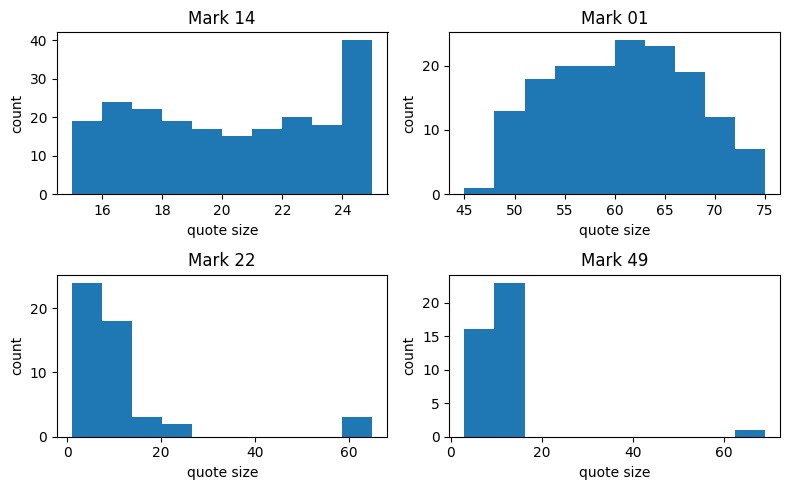

In [418]:
full_quotes_all = {}
for part in makers:
    full_quotes = []
    for ts in part_buys[part].index:
        full_quotes.append(price_velvet.loc[ts, 'bid_volume_1'])
    for ts in part_sells[part].index:
        full_quotes.append(price_velvet.loc[ts, 'ask_volume_1'])
    full_quotes_all[part] = full_quotes

fig, axes = plt.subplots(2, 2, figsize=(8, 5))
for part, ax in zip(makers, axes.flat):
    ax.hist(full_quotes_all[part])
    ax.set_title(part)
    ax.set_xlabel('quote size')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [419]:
print(f"Whale's quoting band: [{min(full_quotes_all[whale])}, {max(full_quotes_all[whale])}]")

Whale's quoting band: [15, 25]


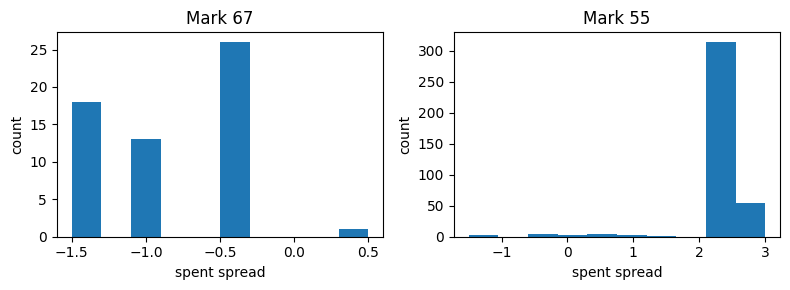

In [420]:
retail_spread_all = {}
for part in takers:
    retail_spread = []
    for ts in part_buys[part].index:
        retail_spread.append(part_buys[part].loc[ts, 'price'] - price_velvet.loc[ts, 'filtered_mid'])
    for ts in part_sells[part].index:
        retail_spread.append(price_velvet.loc[ts, 'filtered_mid'] - part_sells[part].loc[ts, 'price'])
    retail_spread_all[part] = retail_spread

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for part, ax in zip(takers, axes.flat):
    ax.hist(retail_spread_all[part])
    ax.set_title(part)
    ax.set_xlabel('spent spread')
    ax.set_ylabel('count')
plt.tight_layout()
plt.show()

## VEV

--------------------------------------------  VEV_4000  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 14         163        91              72              0               0               4250.0         
Mark 22         1          0               1               0               0               -47.0          
Mark 38         164        0               0               73              91              -4203.0        


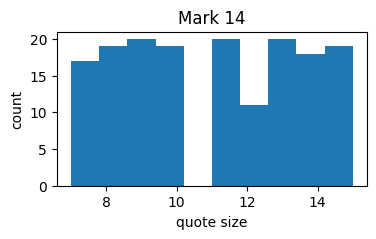

Mark 14 quoting band: [7, 15]

--------------------------------------------  VEV_4500  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 38         1          0               0               1               0               0.0            
Mark 22         1          0               1               0               0               0.0            

--------------------------------------------  VEV_5000  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 38         1          0               0               1               0               0.0            
Mark 22         1          0               1               0               0               0.0            

--------------------------------------------  VEV_5100  --------------------------------------------
Participant     trades

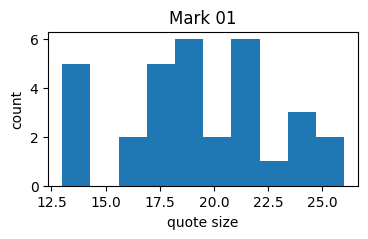

Mark 01 quoting band: [13, 26]


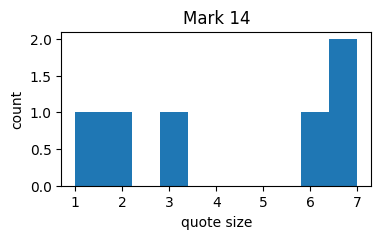

Mark 14 quoting band: [1, 7]

--------------------------------------------  VEV_5400  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 01         76         76              0               0               0               115.0          
Mark 22         81         0               0               0               81              -40.0          
Mark 14         5          5               0               0               0               -75.0          


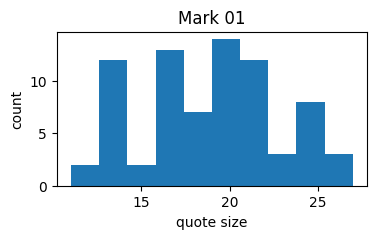

Mark 01 quoting band: [11, 27]


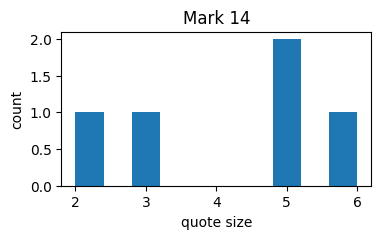

Mark 14 quoting band: [2, 6]

--------------------------------------------  VEV_5500  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 22         92         0               0               0               92              318.0          
Mark 14         3          3               0               0               0               -22.0          
Mark 01         89         89              0               0               0               -296.0         

--------------------------------------------  VEV_6000  --------------------------------------------
Participant     trades     make buys       make sells      take buys       take sells      PnL            
Mark 01         98         98              0               0               0               0.0            
Mark 22         98         0               0               0               98              0.0            

-----------------

In [425]:
for strike in strikes:
    print("-" * 44, f" VEV_{strike} ", "-" * 44)
    trades_velvet = trades[trades['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
    trades_velvet_1 = trades_1[trades_1['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
    trades_velvet_2 = trades_2[trades_2['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
    
    pnls_df, final_prices = calculate_participant_pnls(trades_velvet)
    
    part_trades = {}
    for part in pnls_df['Trader']:
        part_trades[part] = trades_velvet[(trades_velvet['buyer'] == part) | (trades_velvet['seller'] == part)].set_index('timestamp', drop=True)
    part_buys = {}
    for part in pnls_df['Trader']:
        part_buys[part] = part_trades[part][part_trades[part]['buyer'] == part]
    part_sells = {}
    for part in pnls_df['Trader']:
        part_sells[part] = part_trades[part][part_trades[part]['seller'] == part]

    ob_cols = price_vev[strike][['bid_price_1', 'ask_price_1', 'mid_price']]
    for part in pnls_df['Trader']:
        part_buys[part] = part_buys[part].join(ob_cols, how='left')
        part_sells[part] = part_sells[part].join(ob_cols, how='left')

    cols_to_drop = ['bid_price_1', 'ask_price_1', 'mid_price']
    for part in pnls_df['Trader']:
        # Maker: Resting bid was hit (Bought at or below best bid)
        part_buys[part]['making'] = part_buys[part]['price'] <= part_buys[part]['bid_price_1']
        # Taker: Crossed spread to hit ask (Bought at or above best ask)
        part_buys[part]['taking'] = part_buys[part]['price'] >= part_buys[part]['ask_price_1']
        
        # Fallback for executions strictly inside the spread
        unclassified = ~(part_buys[part]['making'] | part_buys[part]['taking'])
        part_buys[part].loc[unclassified, 'making'] = part_buys[part].loc[unclassified, 'price'] < part_buys[part].loc[unclassified, 'mid_price']
        part_buys[part].loc[unclassified, 'taking'] = part_buys[part].loc[unclassified, 'price'] > part_buys[part].loc[unclassified, 'mid_price']
    
        part_buys[part].drop(columns=cols_to_drop, inplace=True)
    
        # Maker: Resting ask was hit (Sold at or above best ask)
        part_sells[part]['making'] = part_sells[part]['price'] >= part_sells[part]['ask_price_1']
        # Taker: Crossed spread to hit bid (Sold at or below best bid)
        part_sells[part]['taking'] = part_sells[part]['price'] <= part_sells[part]['bid_price_1']
        
        # Fallback for executions strictly inside the spread
        unclassified = ~(part_sells[part]['making'] | part_sells[part]['taking'])
        part_sells[part].loc[unclassified, 'making'] = part_sells[part].loc[unclassified, 'price'] > part_sells[part].loc[unclassified, 'mid_price']
        part_sells[part].loc[unclassified, 'taking'] = part_sells[part].loc[unclassified, 'price'] < part_sells[part].loc[unclassified, 'mid_price']
    
        part_sells[part].drop(columns=cols_to_drop, inplace=True)

    print(f"{'Participant':<15} {'trades':<10} {'make buys':<15} {'make sells':<15} {'take buys':<15} {'take sells':<15} {'PnL':<15}")
    for part in pnls_df['Trader']:
        print(f"{part:<15} {part_trades[part].shape[0]:<10}",
              f"{part_buys[part]['making'].sum():<15} {part_sells[part]['making'].sum():<15}",
              f"{part_buys[part]['taking'].sum():<15} {part_sells[part]['taking'].sum():<15}",
              f"{pnls_df[pnls_df['Trader'] == part]['Total_PnL'].values[0]:<15}")

    if strike == 4000:
        part = 'Mark 14'
        full_quotes = []
        for ts in part_buys[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'bid_volume_1'])
        for ts in part_sells[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'ask_volume_1'])
        plt.figure(figsize=(4, 2))
        plt.hist(full_quotes)
        plt.title(part)
        plt.xlabel('quote size')
        plt.ylabel('count')
        plt.show()
        print(f"{part} quoting band: [{min(full_quotes)}, {max(full_quotes)}]")

    if strike == 5300 or strike == 5400:
        part = 'Mark 01'
        full_quotes = []
        for ts in part_buys[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'bid_volume_1'])
        for ts in part_sells[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'ask_volume_1'])
        plt.figure(figsize=(4, 2))
        plt.hist(full_quotes)
        plt.title(part)
        plt.xlabel('quote size')
        plt.ylabel('count')
        plt.show()
        print(f"{part} quoting band: [{min(full_quotes)}, {max(full_quotes)}]")
        part = 'Mark 14'
        full_quotes = []
        for ts in part_buys[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'bid_volume_1'])
        for ts in part_sells[part].index:
            full_quotes.append(price_vev[strike].loc[ts, 'ask_volume_1'])
        plt.figure(figsize=(4, 2))
        plt.hist(full_quotes)
        plt.title(part)
        plt.xlabel('quote size')
        plt.ylabel('count')
        plt.show()
        print(f"{part} quoting band: [{min(full_quotes)}, {max(full_quotes)}]")

    print()

In [422]:
whale = 'Mark 14'
retail = 'Mark 38'
print(f"Whale: {whale}  --  Retail: {retail}")

Whale: Mark 14  --  Retail: Mark 38


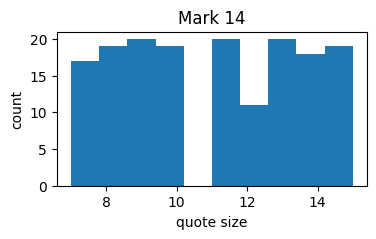

Whale's quoting band: [7, 15]


In [347]:
strike = 4000
trades_velvet = trades[trades['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
trades_velvet_1 = trades_1[trades_1['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
trades_velvet_2 = trades_2[trades_2['symbol'] == f'VEV_{strike}'].reset_index(drop=True)

pnls_df, final_prices = calculate_participant_pnls(trades_velvet)

part_trades = {}
for part in pnls_df['Trader']:
    part_trades[part] = trades_velvet[(trades_velvet['buyer'] == part) | (trades_velvet['seller'] == part)].set_index('timestamp', drop=True)
part_buys = {}
for part in pnls_df['Trader']:
    part_buys[part] = part_trades[part][part_trades[part]['buyer'] == part]
part_sells = {}
for part in pnls_df['Trader']:
    part_sells[part] = part_trades[part][part_trades[part]['seller'] == part]

ob_cols = price_vev[strike][['bid_price_1', 'ask_price_1', 'mid_price']]
for part in pnls_df['Trader']:
    part_buys[part] = part_buys[part].join(ob_cols, how='left')
    part_sells[part] = part_sells[part].join(ob_cols, how='left')

cols_to_drop = ['bid_price_1', 'ask_price_1', 'mid_price']
for part in pnls_df['Trader']:
    # Maker: Resting bid was hit (Bought at or below best bid)
    part_buys[part]['making'] = part_buys[part]['price'] <= part_buys[part]['bid_price_1']
    # Taker: Crossed spread to hit ask (Bought at or above best ask)
    part_buys[part]['taking'] = part_buys[part]['price'] >= part_buys[part]['ask_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_buys[part]['making'] | part_buys[part]['taking'])
    part_buys[part].loc[unclassified, 'making'] = part_buys[part].loc[unclassified, 'price'] < part_buys[part].loc[unclassified, 'mid_price']
    part_buys[part].loc[unclassified, 'taking'] = part_buys[part].loc[unclassified, 'price'] > part_buys[part].loc[unclassified, 'mid_price']

    part_buys[part].drop(columns=cols_to_drop, inplace=True)

    # Maker: Resting ask was hit (Sold at or above best ask)
    part_sells[part]['making'] = part_sells[part]['price'] >= part_sells[part]['ask_price_1']
    # Taker: Crossed spread to hit bid (Sold at or below best bid)
    part_sells[part]['taking'] = part_sells[part]['price'] <= part_sells[part]['bid_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_sells[part]['making'] | part_sells[part]['taking'])
    part_sells[part].loc[unclassified, 'making'] = part_sells[part].loc[unclassified, 'price'] > part_sells[part].loc[unclassified, 'mid_price']
    part_sells[part].loc[unclassified, 'taking'] = part_sells[part].loc[unclassified, 'price'] < part_sells[part].loc[unclassified, 'mid_price']

    part_sells[part].drop(columns=cols_to_drop, inplace=True)

part = whale
full_quotes = []
for ts in part_buys[part].index:
    full_quotes.append(price_vev[strike].loc[ts, 'bid_volume_1'])
for ts in part_sells[part].index:
    full_quotes.append(price_vev[strike].loc[ts, 'ask_volume_1'])

plt.figure(figsize=(4, 2))
plt.hist(full_quotes)
plt.title(part)
plt.xlabel('quote size')
plt.ylabel('count')
plt.show()

print(f"Whale's quoting band: [{min(full_quotes)}, {max(full_quotes)}]")

In [ ]:
strike = 4000
trades_velvet = trades[trades['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
trades_velvet_1 = trades_1[trades_1['symbol'] == f'VEV_{strike}'].reset_index(drop=True)
trades_velvet_2 = trades_2[trades_2['symbol'] == f'VEV_{strike}'].reset_index(drop=True)

pnls_df, final_prices = calculate_participant_pnls(trades_velvet)

part_trades = {}
for part in pnls_df['Trader']:
    part_trades[part] = trades_velvet[(trades_velvet['buyer'] == part) | (trades_velvet['seller'] == part)].set_index('timestamp', drop=True)
part_buys = {}
for part in pnls_df['Trader']:
    part_buys[part] = part_trades[part][part_trades[part]['buyer'] == part]
part_sells = {}
for part in pnls_df['Trader']:
    part_sells[part] = part_trades[part][part_trades[part]['seller'] == part]

ob_cols = price_vev[strike][['bid_price_1', 'ask_price_1', 'mid_price']]
for part in pnls_df['Trader']:
    part_buys[part] = part_buys[part].join(ob_cols, how='left')
    part_sells[part] = part_sells[part].join(ob_cols, how='left')

cols_to_drop = ['bid_price_1', 'ask_price_1', 'mid_price']
for part in pnls_df['Trader']:
    # Maker: Resting bid was hit (Bought at or below best bid)
    part_buys[part]['making'] = part_buys[part]['price'] <= part_buys[part]['bid_price_1']
    # Taker: Crossed spread to hit ask (Bought at or above best ask)
    part_buys[part]['taking'] = part_buys[part]['price'] >= part_buys[part]['ask_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_buys[part]['making'] | part_buys[part]['taking'])
    part_buys[part].loc[unclassified, 'making'] = part_buys[part].loc[unclassified, 'price'] < part_buys[part].loc[unclassified, 'mid_price']
    part_buys[part].loc[unclassified, 'taking'] = part_buys[part].loc[unclassified, 'price'] > part_buys[part].loc[unclassified, 'mid_price']

    part_buys[part].drop(columns=cols_to_drop, inplace=True)

    # Maker: Resting ask was hit (Sold at or above best ask)
    part_sells[part]['making'] = part_sells[part]['price'] >= part_sells[part]['ask_price_1']
    # Taker: Crossed spread to hit bid (Sold at or below best bid)
    part_sells[part]['taking'] = part_sells[part]['price'] <= part_sells[part]['bid_price_1']
    
    # Fallback for executions strictly inside the spread
    unclassified = ~(part_sells[part]['making'] | part_sells[part]['taking'])
    part_sells[part].loc[unclassified, 'making'] = part_sells[part].loc[unclassified, 'price'] > part_sells[part].loc[unclassified, 'mid_price']
    part_sells[part].loc[unclassified, 'taking'] = part_sells[part].loc[unclassified, 'price'] < part_sells[part].loc[unclassified, 'mid_price']

    part_sells[part].drop(columns=cols_to_drop, inplace=True)

part = whale
full_quotes = []
for ts in part_buys[part].index:
    full_quotes.append(price_vev[strike].loc[ts, 'bid_volume_1'])
for ts in part_sells[part].index:
    full_quotes.append(price_vev[strike].loc[ts, 'ask_volume_1'])

plt.figure(figsize=(4, 2))
plt.hist(full_quotes)
plt.title(part)
plt.xlabel('quote size')
plt.ylabel('count')
plt.show()

print(f"Whale's quoting band: [{min(full_quotes)}, {max(full_quotes)}]")

# Options

In [25]:
for strike in strikes:
    price_vev[strike]['spot'] = price_velvet['filtered_mid']
    price_vev[strike]['intrinsic'] = np.max([price_vev[strike]['spot'] - price_vev[strike]['strike'], np.zeros(price_vev[strike].shape[0])], axis=0)
    price_vev[strike]['filtered_mid'] = price_vev[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev[strike]['implied_vol'] = price_vev[strike].apply(calc_implied_vol, axis=1)

    price_vev[strike]['vega'] = price_vev[strike].apply(calc_vega, axis=1)
    price_vev[strike]['implied_vol'] = price_vev[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev[strike]['delta'] = price_vev[strike].apply(calc_delta, axis=1)
    price_vev[strike]['gamma'] = price_vev[strike].apply(calc_gamma, axis=1)
    price_vev[strike]['vega'] = price_vev[strike].apply(calc_vega, axis=1)

    price_vev[strike]['moneyness'] = price_vev[strike].apply(calc_moneyness, axis=1)

In [26]:
for strike in strikes:
    price_vev_1[strike]['spot'] = price_velvet_1['filtered_mid']
    price_vev_1[strike]['intrinsic'] = np.max([price_vev_1[strike]['spot'] - price_vev_1[strike]['strike'], np.zeros(price_vev_1[strike].shape[0])], axis=0)
    price_vev_1[strike]['filtered_mid'] = price_vev_1[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev_1[strike]['implied_vol'] = price_vev_1[strike].apply(calc_implied_vol, axis=1)

    price_vev_1[strike]['vega'] = price_vev_1[strike].apply(calc_vega, axis=1)
    price_vev_1[strike]['implied_vol'] = price_vev_1[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev_1[strike]['delta'] = price_vev_1[strike].apply(calc_delta, axis=1)
    price_vev_1[strike]['gamma'] = price_vev_1[strike].apply(calc_gamma, axis=1)
    price_vev_1[strike]['vega'] = price_vev_1[strike].apply(calc_vega, axis=1)

    price_vev_1[strike]['moneyness'] = price_vev_1[strike].apply(calc_moneyness, axis=1)

In [27]:
for strike in strikes:
    price_vev_2[strike]['spot'] = price_velvet_2['filtered_mid']
    price_vev_2[strike]['intrinsic'] = np.max([price_vev_2[strike]['spot'] - price_vev_2[strike]['strike'], np.zeros(price_vev_2[strike].shape[0])], axis=0)
    price_vev_2[strike]['filtered_mid'] = price_vev_2[strike].apply(lambda x: x['intrinsic'] if x['mid_price'] < x['intrinsic'] else x['mid_price'], axis=1)
    price_vev_2[strike]['implied_vol'] = price_vev_2[strike].apply(calc_implied_vol, axis=1)

    price_vev_2[strike]['vega'] = price_vev_2[strike].apply(calc_vega, axis=1)
    price_vev_2[strike]['implied_vol'] = price_vev_2[strike].apply(lambda x: x['implied_vol'] if x['vega'] > 1e-6 else None, axis=1)  # filter 0 vega
    
    price_vev_2[strike]['delta'] = price_vev_2[strike].apply(calc_delta, axis=1)
    price_vev_2[strike]['gamma'] = price_vev_2[strike].apply(calc_gamma, axis=1)
    price_vev_2[strike]['vega'] = price_vev_2[strike].apply(calc_vega, axis=1)

    price_vev_2[strike]['moneyness'] = price_vev_2[strike].apply(calc_moneyness, axis=1)

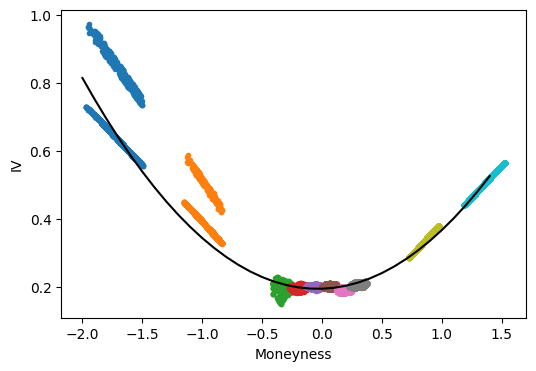

In [28]:
m_list, v_list = [], []
for strike in strikes:
    m_list.extend(list(price_vev[strike][price_vev[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev[strike][price_vev[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))
    m_list.extend(list(price_vev_1[strike][price_vev_1[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev_1[strike][price_vev_1[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))
    m_list.extend(list(price_vev_2[strike][price_vev_2[strike]['implied_vol'].notna()]['moneyness'].to_numpy()))
    v_list.extend(list(price_vev_2[strike][price_vev_2[strike]['implied_vol'].notna()]['implied_vol'].to_numpy()))

a, b, c = np.polyfit(m_list, v_list, 2)
modelled = a * (np.arange(-20, 15) / 10) ** 2 + b * np.arange(-20, 15) / 10 + c

plt.figure(figsize=(6, 4))
for strike in strikes:
    df = pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])
    plt.scatter(df['moneyness'], df['implied_vol'], marker='.')
plt.plot(np.arange(-20, 15) / 10, modelled, c='k')
plt.xlabel('Moneyness')
plt.ylabel('IV')
plt.show()

In [29]:
print(a, b, c)

0.16082565883588573 0.011712929482911333 0.19478728225341402


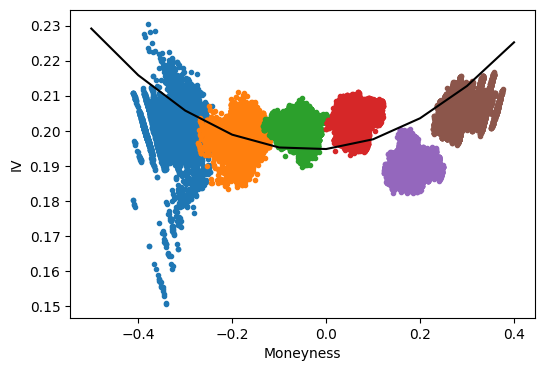

In [30]:
modelled = a * (np.arange(-5, 5) / 10) ** 2 + b * np.arange(-5, 5) / 10 + c

plt.figure(figsize=(6, 4))
for strike in atm_strikes:
    df = pd.concat([price_vev[strike], price_vev_1[strike], price_vev_2[strike]])
    plt.scatter(df['moneyness'], df['implied_vol'], marker='.')
plt.plot(np.arange(-5, 5) / 10, modelled, c='k')
plt.xlabel('Moneyness')
plt.ylabel('IV')
plt.show()